# EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
# dataset has already been cleaned by preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("processed_insurance_claims.csv")

In [ ]:
# univariate analysis - numerical features

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
df[numeric_cols].describe().T  # gives count, mean, std, min, quartiles, max for every numeric
# column in one shot to spot obviously wrong values (negative age, unusual claim amount)

Numeric columns: ['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']


,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


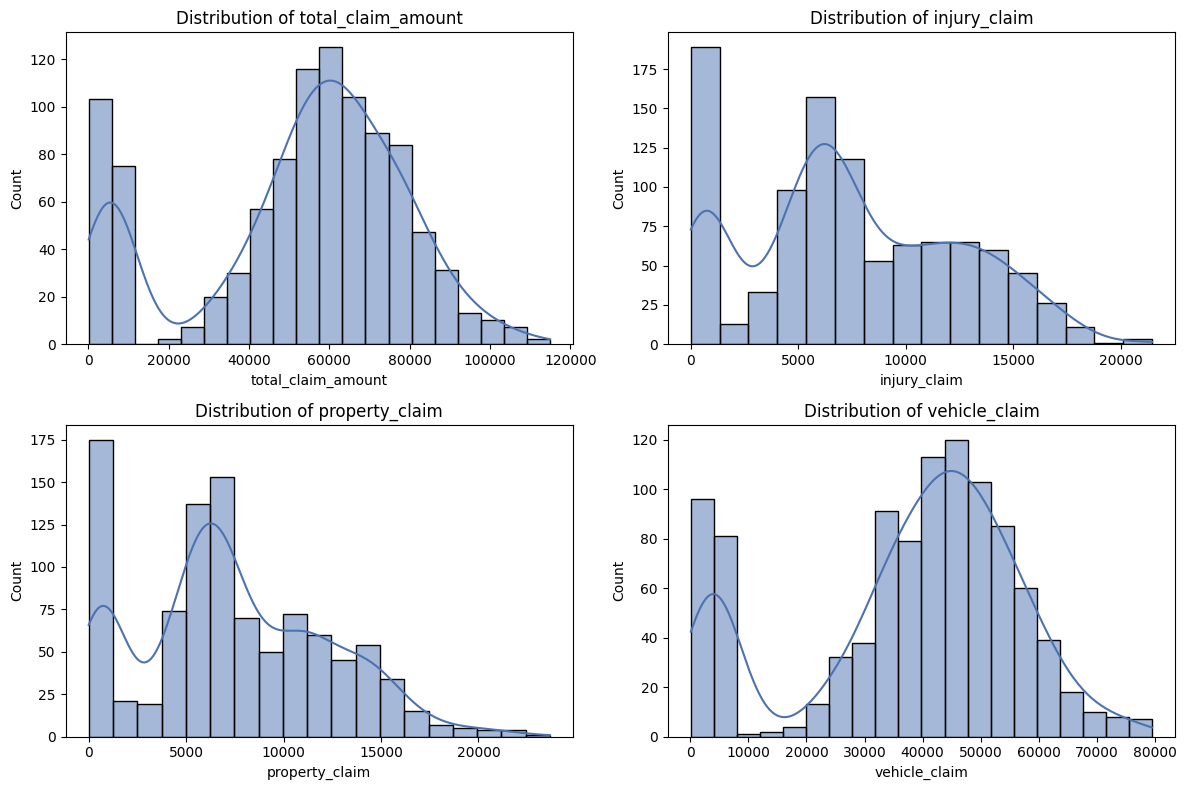

In [ ]:
# Key financial columns to look at as distributions for our "claim severity estimation" objective
financial_cols = ["total_claim_amount", "injury_claim", "property_claim", "vehicle_claim"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), financial_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("plots 02_financial_distributions.png", dpi=120)
plt.show()

total_claim_amount and its components (injury/property/vehicle claim) are right-skewed: most claims are moderate, but a smaller number are very large. This is typical for financial/severity data.
It justifies later trying a log-transform of the target if we build a regression model for severity, or bucketing severity into categories (Low/Medium/High) for a classification-style severity model.

In [ ]:
# check suspicious or unusual values
# capital-loss is stored as a negative number ( asit IS a loss)
# but first confirm ranges & check for genuinely impossible values.

print("age range:", df["age"].min(), "-", df["age"].max())
print("months_as_customer range:", df["months_as_customer"].min(), "-", df["months_as_customer"].max())
print("umbrella_limit unique sample:", sorted(df["umbrella_limit"].unique())[:5], "...")
print("negative umbrella_limit rows:", (df["umbrella_limit"] < 0).sum())

age range: 19 - 64
months_as_customer range: 0 - 479
umbrella_limit unique sample: [np.int64(-1000000), np.int64(0), np.int64(2000000), np.int64(3000000), np.int64(4000000)] ...
negative umbrella_limit rows: 1


umbrella_limit occasionally has a -1000000 entry in this dataset: almost certainly a data-entry artifact (an umbrella policy limit cannot be
negative).
We flag it rather than silently deleting rows, since ver less no. of rows and dropping them could bias the (already imbalanced) fraud classes.

In [ ]:
print(df.loc[df["umbrella_limit"] < 0, ["umbrella_limit", "fraud_reported"]])

     umbrella_limit fraud_reported
290        -1000000              N


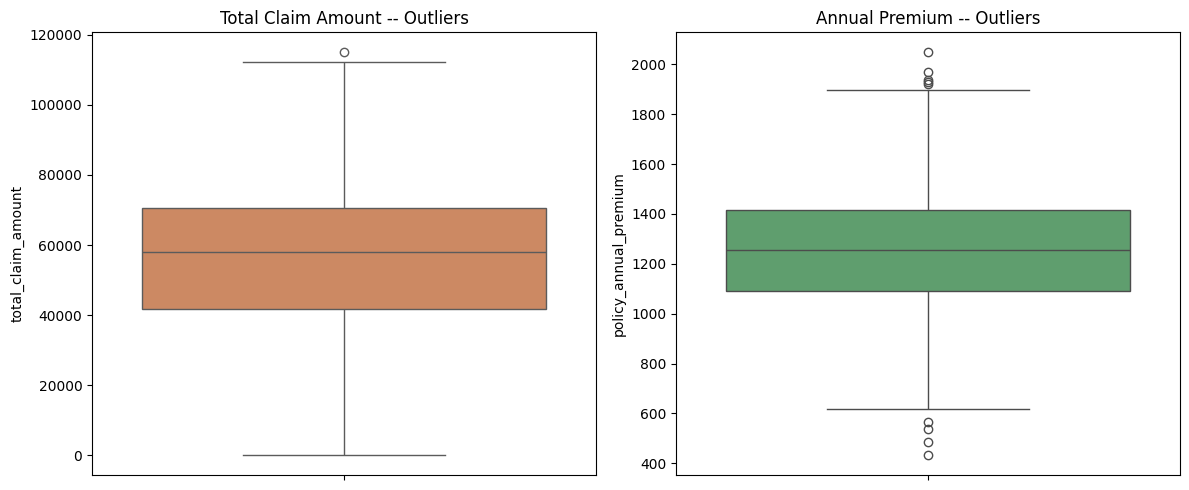

total_claim_amount: 1 outlier rows (IQR method)
policy_annual_premium: 9 outlier rows (IQR method)
vehicle_claim: 0 outlier rows (IQR method)


In [ ]:
#outlier detection using boxplots(IQR METHOD)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, y="total_claim_amount", ax=axes[0], color="#dd8452")
axes[0].set_title("Total Claim Amount -- Outliers")
sns.boxplot(data=df, y="policy_annual_premium", ax=axes[1], color="#55a868")
axes[1].set_title("Annual Premium -- Outliers")
plt.tight_layout()
plt.savefig("plots 03_outlier_boxplots.png", dpi=120)
plt.show()

# We compute IQR bounds explicitly, since our report should quantify "how many outliers"

def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["total_claim_amount", "policy_annual_premium", "vehicle_claim"]:
    print(f"{col}: {iqr_outlier_count(df[col])} outlier rows (IQR method)")

In fraud detection, outliers are NOT automatically "bad data"-an unusually large or unusual claim issomething fraud detection is supposed to catch.

Document outliers for awareness, but deliberately do not remove them at this stage.

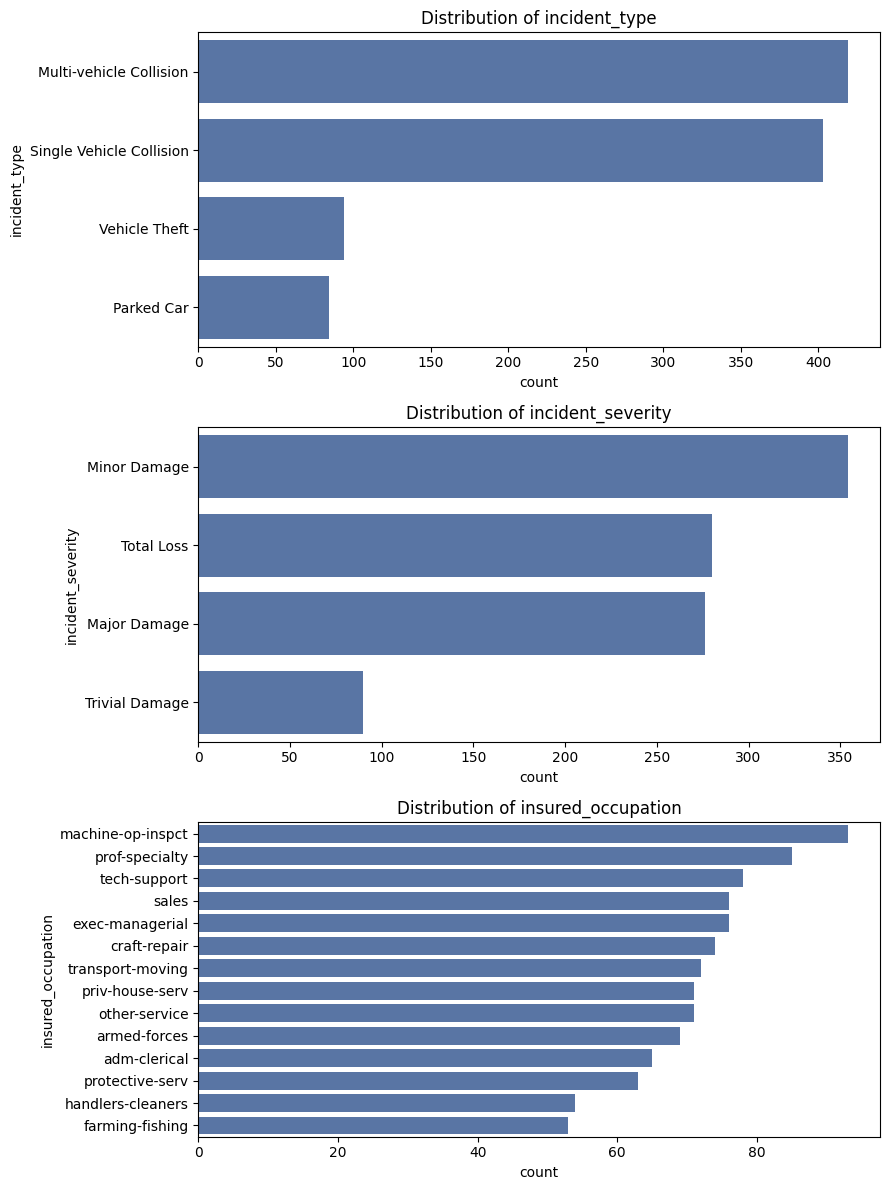

In [ ]:
# categorical feature distributions

cat_cols_to_plot = ["incident_type", "incident_severity", "insured_occupation"]

fig, axes = plt.subplots(3, 1, figsize=(9, 12))
for ax, col in zip(axes, cat_cols_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4c72b0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("plots 04_categorical_distributions.png", dpi=120)
plt.show()

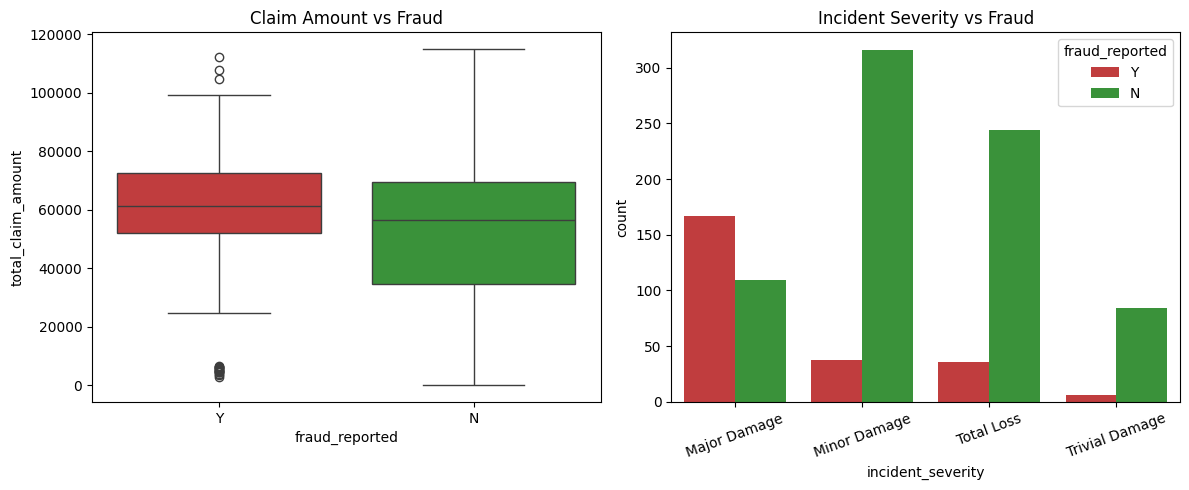

In [ ]:
# bivariate analysis: FEATURE vs FRAUD TARGET
'''
This is the most important EDA for our objective: which features
actually differ between fraudulent and legitimate claims? This directly
informs which features are worth engineering/keeping for the model, and
gives us a preview of what a SHAP explainability analysis should later confirm at the model level.
'''

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="fraud_reported", y="total_claim_amount", ax=axes[0],
            hue="fraud_reported", palette={"Y": "#d62728", "N": "#2ca02c"}, legend=False)
axes[0].set_title("Claim Amount vs Fraud")

sns.countplot(data=df, x="incident_severity", hue="fraud_reported", ax=axes[1],
              palette={"Y": "#d62728", "N": "#2ca02c"})
axes[1].set_title("Incident Severity vs Fraud")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("plots 05_bivariate_fraud_analysis.png", dpi=120)
plt.show()

In [ ]:
# Fraud rate broken down by incident_severity, as a table (easier to quote exact numbers in a report :
fraud_rate_by_severity = (
    df.groupby("incident_severity")["fraud_reported"]
    .apply(lambda x: (x == "Y").mean())
    .sort_values(ascending=False)
    .round(3)
)
print("Fraud rate by incident severity:\n", fraud_rate_by_severity)

Fraud rate by incident severity:
 incident_severity
Major Damage      0.605
Total Loss        0.129
Minor Damage      0.107
Trivial Damage    0.067
Name: fraud_reported, dtype: float64


"Major Damage" claims tend to show a noticeably higher fraud rate than
"Trivial/Minor Damage" claims.
This is a genuinely useful signal, and it's
exactly the kind of feature-target relationship our fraud model should
pick up on.

A correlation heatmap helps us spot MULTICOLLINEARITY: pairs of features that carry almost the same information. Highly correlated features can destabilize some models and make SHAP explanations harder to interpret.

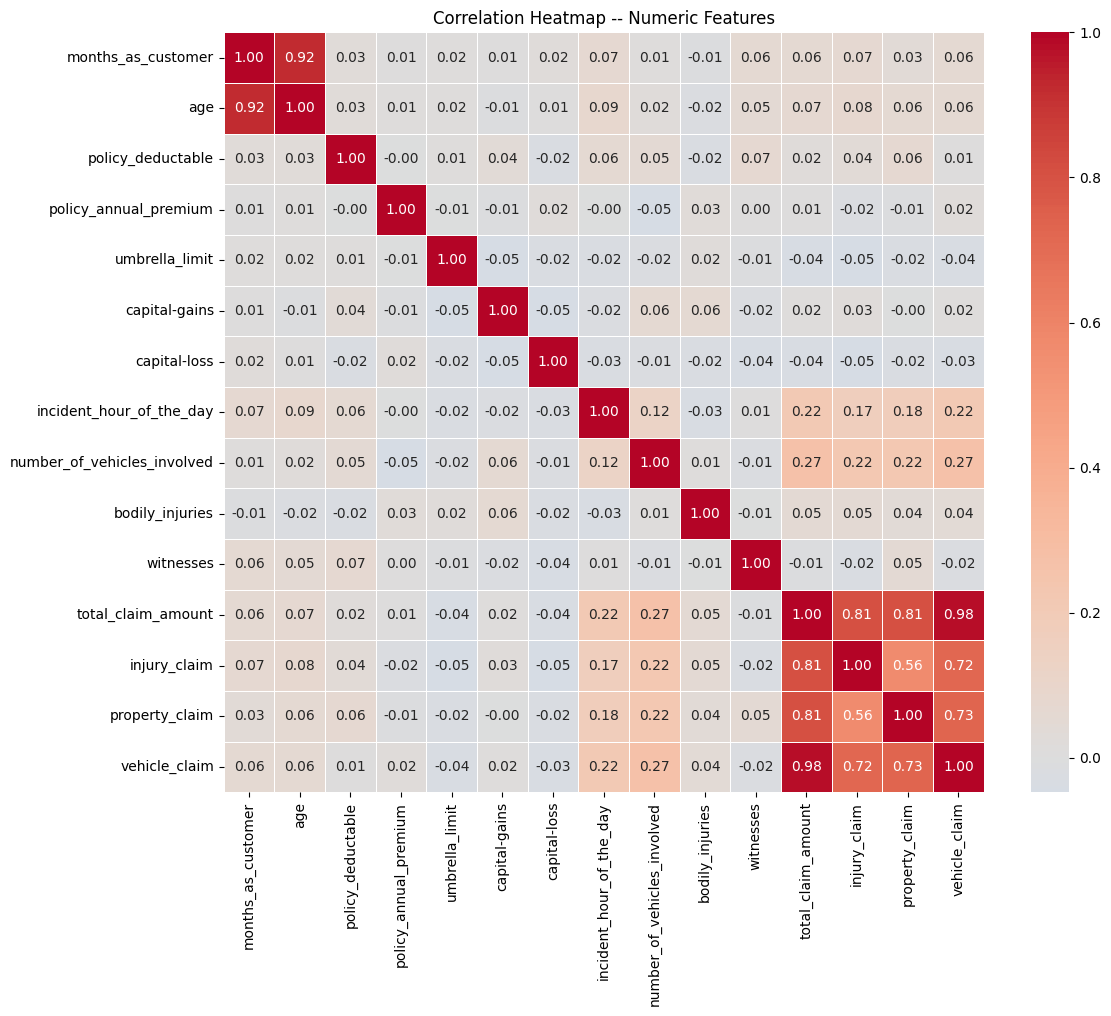

In [ ]:
corr_cols = [
    "months_as_customer", "age", "policy_deductable", "policy_annual_premium",
    "umbrella_limit", "capital-gains", "capital-loss", "incident_hour_of_the_day",
    "number_of_vehicles_involved", "bodily_injuries", "witnesses",
    "total_claim_amount", "injury_claim", "property_claim", "vehicle_claim",
]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap -- Numeric Features")
plt.tight_layout()
plt.savefig("plots 06_correlation_heatmap.png", dpi=120)
plt.show()

 As expected, total_claim_amount is very highly correlated with
 injury_claim, property_claim, and vehicle_claim, because by construction:
#### total_claim_amount = injury_claim + property_claim + vehicle_claim.
 If we feed ALL FOUR of these into a model
 together, we are essentially giving it the same information four times
 (data leakage / redundancy), which inflates its apparent importance and
 confuses explainability.
 In Feature Extraction, we can keep the three components and drop the total OR engineer ratio features from them instead of using both forms raw.
 'age' and 'months_as_customer' also show a moderate positive correlation
 (as older customers have naturally had more time to accumulate tenure).